# RAF-DB Training Creation
Notebook for creating a training file matching api pulled data for RAF-DB

In [13]:
import polars as pl
from pathlib import Path
import plotly.express as px

In [14]:
def bar_plot_counts(df, col):
    counts_df = df[col].value_counts().sort("count", descending=True)
    fig = px.bar(counts_df, x=col, y="count", title="Value Counts Bar Plot")
    fig.show()

In [15]:
raf_base = Path('../data/raf-db/DATASET')
data_source = 'raf-db'

In [16]:
pwd

'/home/dxd/Documents/face-value/notebooks'

In [17]:
def process_split(split_name):
    """Process one split (train or test)"""
    split_dir = raf_base / split_name
    
    if not split_dir.exists():
        print(f"Warning: {split_dir} does not exist")
        return None
    
    records = []
    print(split_dir)
    for emotion_dir in split_dir.iterdir():
        print(emotion_dir)
        if not emotion_dir.is_dir():
            continue
            
        emotion = emotion_dir.name
        
        for img_path in emotion_dir.glob('*.jpg'):
            records.append({
                'data_source': data_source,
                'face_path': '../data/raf-db/' + str(img_path.relative_to(raf_base.parent)),
                'emotion': emotion
            })
    
    return pl.DataFrame(records)

In [19]:
# Process train
train_df = process_split('train')
train_df.head()
if train_df is not None:
    print(f"Train: {len(train_df)} images")
    print(train_df['emotion'].value_counts().sort('emotion'))
    train_df.write_parquet(raf_base / 'raf_train.parquet')

../data/raf-db/DATASET/train
../data/raf-db/DATASET/train/sad
../data/raf-db/DATASET/train/neutral
../data/raf-db/DATASET/train/disgust
../data/raf-db/DATASET/train/surprise
../data/raf-db/DATASET/train/fear
../data/raf-db/DATASET/train/happy
../data/raf-db/DATASET/train/angry
Train: 12271 images
shape: (7, 2)
┌──────────┬───────┐
│ emotion  ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ angry    ┆ 705   │
│ disgust  ┆ 717   │
│ fear     ┆ 281   │
│ happy    ┆ 4772  │
│ neutral  ┆ 2524  │
│ sad      ┆ 1982  │
│ surprise ┆ 1290  │
└──────────┴───────┘


In [26]:
# Process test
test_df = process_split('test')
if test_df is not None:
    print(f"\nTest: {len(test_df)} images")
    print(test_df['emotion'].value_counts().sort('emotion'))
    test_df.write_parquet(raf_base / 'raf_test.parquet')

../data/raf-db/DATASET/test
../data/raf-db/DATASET/test/sad
../data/raf-db/DATASET/test/neutral
../data/raf-db/DATASET/test/disgust
../data/raf-db/DATASET/test/surprise
../data/raf-db/DATASET/test/fear
../data/raf-db/DATASET/test/happy
../data/raf-db/DATASET/test/angry

Test: 3068 images
shape: (7, 2)
┌──────────┬───────┐
│ emotion  ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ angry    ┆ 162   │
│ disgust  ┆ 160   │
│ fear     ┆ 74    │
│ happy    ┆ 1185  │
│ neutral  ┆ 680   │
│ sad      ┆ 478   │
│ surprise ┆ 329   │
└──────────┴───────┘


In [27]:
# dropped unused emotions
drop_list = ['disgust', 'neutral']

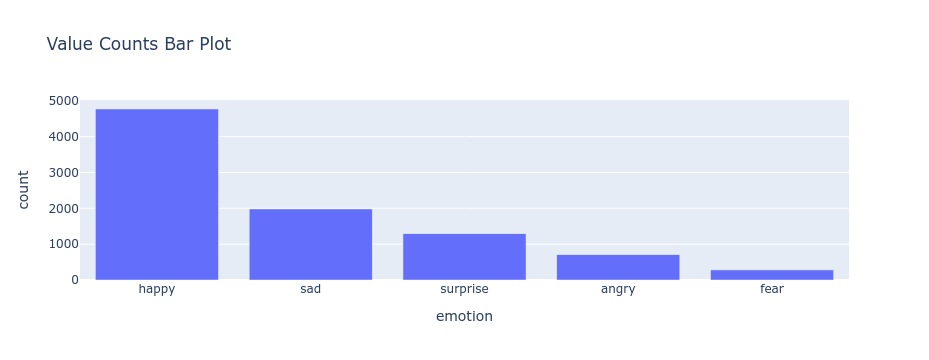

In [28]:
train_cut =  train_df.filter(~pl.col('emotion').is_in(drop_list))

bar_plot_counts(train_cut, 'emotion')

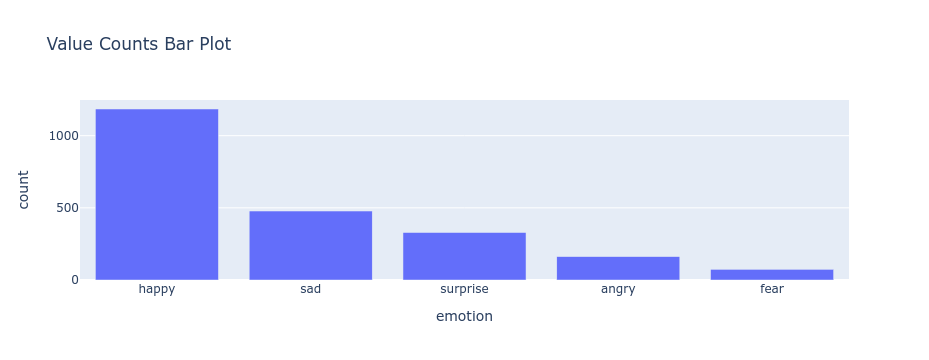

In [29]:
test_cut = test_df.filter(~pl.col('emotion').is_in(drop_list))

bar_plot_counts(test_cut, 'emotion')

In [30]:
train_cut.write_parquet(raf_base / 'raf_train_trimmed.parquet')
test_cut.write_parquet(raf_base / 'raf_test_trimmed.parquet')

In [31]:
train_df

data_source,face_path,emotion
str,str,str
"""raf-db""","""../data/raf-db/DATASET/train/s…","""sad"""
"""raf-db""","""../data/raf-db/DATASET/train/s…","""sad"""
"""raf-db""","""../data/raf-db/DATASET/train/s…","""sad"""
"""raf-db""","""../data/raf-db/DATASET/train/s…","""sad"""
"""raf-db""","""../data/raf-db/DATASET/train/s…","""sad"""
…,…,…
"""raf-db""","""../data/raf-db/DATASET/train/a…","""angry"""
"""raf-db""","""../data/raf-db/DATASET/train/a…","""angry"""
"""raf-db""","""../data/raf-db/DATASET/train/a…","""angry"""
